In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns # iris(데이터프레임)가져오기
from sklearn import datasets # iris(X와 y가 분리되서 numpy) 가져오기
from sklearn.preprocessing import LabelEncoder # 라벨 인코더
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Dropout

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from matplotlib import pyplot as plt

```
- 데이터셋 생성 및 전처리
    X, y(라벨인코딩)분리 -> train_test_split 분리(8:2)
- 모델 구성(입력4, 출력3, layer : 4->64->128->50->30->3)
- 학습과정 설정 (loss='sparse_categorical_crossentropy')
- 학습
- 모델평가(가장 최선의 모델을 get)
- 모델 사용(저장/예측)
```
# 1. 기본적인 DNN
## 1. 데이터 셋 생성 및 전처리

In [5]:
# iris가져오기 방법 1
iris = sns.load_dataset('iris')
iris['species'].value_counts()

setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

In [12]:
iris_X = iris.iloc[:, :-1].values
labelEncoder = LabelEncoder()
iris_y = labelEncoder.fit_transform(iris.iloc[:, -1]) # 0:setosa/1:versicolor/2:virginica
iris_X.shape, iris_y.shape

((150, 4), (150,))

In [15]:
# iris가져오기 방법 2
iris = datasets.load_iris()
iris_X = iris.data
iris_y = iris.target
print(iris.target_names)
iris_X.shape, iris_y.shape

['setosa' 'versicolor' 'virginica']


((150, 4), (150,))

In [24]:
# 학습셋과 테스트셋 분리
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                   test_size=0.2,
                                                   stratify=iris_y # 층화추출
                                                   )
np.c_[pd.Series(iris_y).value_counts(normalize=True),
      pd.Series(train_y).value_counts(normalize=True),
      pd.Series(test_y).value_counts(normalize=True)]

array([[0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333]])

In [25]:
train_X.shape, train_y.shape, test_X.shape, test_y.shape

((120, 4), (120,), (30, 4), (30,))

## 2. 모델 구성 및 학습
- 4->64->128->50->30->3
- He초기화, 다양한 activation, 배치정규화, L2정규화, Dropout

In [47]:
model = Sequential([
    Input(4),
    Dense(units=64, activation='relu'),
    Dense(units=128, activation='relu'),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax'),
], 'sequential')
# model = Sequential(name='sequential')
# model.add(Input(4))
# model.add(Dense(units=64, activation='relu'))
# model.add(Dense(units=128, activation='relu'))
# model.add(Dense(units=50, activation='relu'))
# model.add(Dense(units=30, activation='relu'))
# model.add(Dense(units=3, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_25 (Dense)            (None, 64)                320       
                                                                 
 dense_26 (Dense)            (None, 128)               8320      
                                                                 
 dense_27 (Dense)            (None, 50)                6450      
                                                                 
 dense_28 (Dense)            (None, 30)                1530      
                                                                 
 dense_29 (Dense)            (None, 3)                 93        
                                                                 
Total params: 16,713
Trainable params: 16,713
Non-trainable params: 0
_________________________________________________________________


In [48]:
%%time
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
earlystopping = EarlyStopping(patience=40) # monitor='val_loss'가 기본값
model_save_folder = 'model/'
import os
if not os.path.exists(model_save_folder):
    os.mkdir(model_save_folder)
file = model_save_folder + 'iris-{epoch:03d}-loss{val_loss:.4f}-acc{val_accuracy:.4f}.h5'
checkpoint = ModelCheckpoint(monitor='val_accuracy',
                            filepath=file, # 모델 저장 파일
                            save_best_only=True, # 모니터 지표가 개선된 경우만 모델 저장
                            mode='max',
                            verbose=1) # 저장 여부 로그 출력
hist = model.fit(train_X, train_y,
                epochs=200,
                validation_split=0.1,
                callbacks=[earlystopping, checkpoint],
                verbose=0)


Epoch 1: val_accuracy improved from -inf to 1.00000, saving model to model\iris-001-loss0.8951-acc1.0000.h5

Epoch 2: val_accuracy did not improve from 1.00000

Epoch 3: val_accuracy did not improve from 1.00000

Epoch 4: val_accuracy did not improve from 1.00000

Epoch 5: val_accuracy did not improve from 1.00000

Epoch 6: val_accuracy did not improve from 1.00000

Epoch 7: val_accuracy did not improve from 1.00000

Epoch 8: val_accuracy did not improve from 1.00000

Epoch 9: val_accuracy did not improve from 1.00000

Epoch 10: val_accuracy did not improve from 1.00000

Epoch 11: val_accuracy did not improve from 1.00000

Epoch 12: val_accuracy did not improve from 1.00000

Epoch 13: val_accuracy did not improve from 1.00000

Epoch 14: val_accuracy did not improve from 1.00000

Epoch 15: val_accuracy did not improve from 1.00000

Epoch 16: val_accuracy did not improve from 1.00000

Epoch 17: val_accuracy did not improve from 1.00000

Epoch 18: val_accuracy did not improve from 1.0000


Epoch 154: val_accuracy did not improve from 1.00000

Epoch 155: val_accuracy did not improve from 1.00000

Epoch 156: val_accuracy did not improve from 1.00000

Epoch 157: val_accuracy did not improve from 1.00000

Epoch 158: val_accuracy did not improve from 1.00000

Epoch 159: val_accuracy did not improve from 1.00000

Epoch 160: val_accuracy did not improve from 1.00000

Epoch 161: val_accuracy did not improve from 1.00000

Epoch 162: val_accuracy did not improve from 1.00000

Epoch 163: val_accuracy did not improve from 1.00000

Epoch 164: val_accuracy did not improve from 1.00000

Epoch 165: val_accuracy did not improve from 1.00000

Epoch 166: val_accuracy did not improve from 1.00000

Epoch 167: val_accuracy did not improve from 1.00000

Epoch 168: val_accuracy did not improve from 1.00000

Epoch 169: val_accuracy did not improve from 1.00000

Epoch 170: val_accuracy did not improve from 1.00000

Epoch 171: val_accuracy did not improve from 1.00000

Epoch 172: val_accuracy did

## 3. 모델 평가

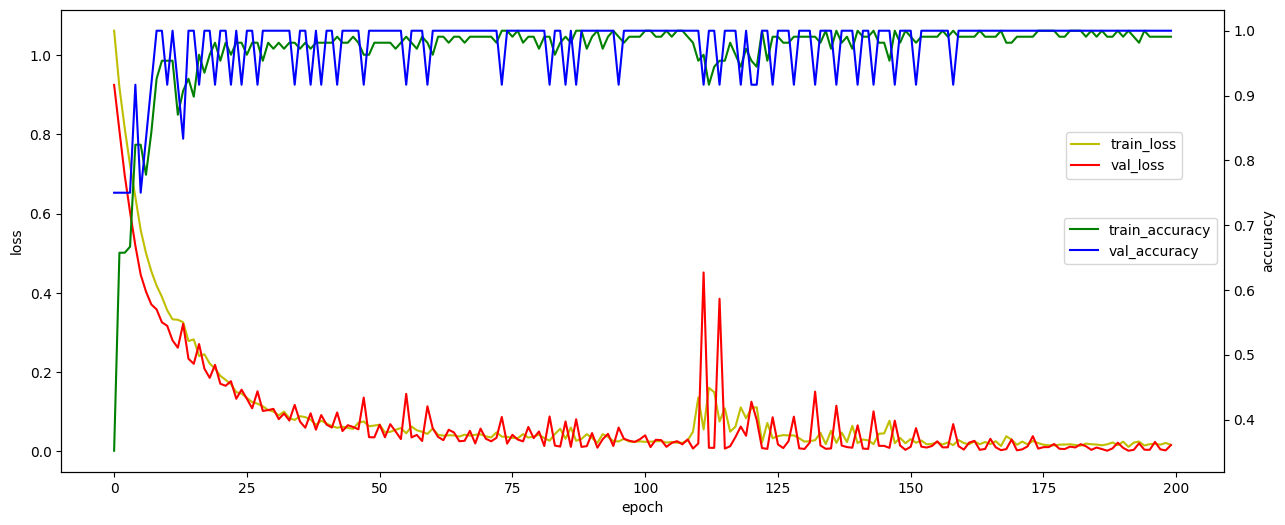

In [44]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()

In [46]:
# 모델 평가
model.evaluate(test_X, test_y)

1/1 [==============================] - 0s 28ms/step - loss: 0.2440 - accuracy: 0.9000


[0.24396467208862305, 0.8999999761581421]